In [1]:
# imports

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import cartopy.io.shapereader as shpreader
from shapely.geometry import Point
from shapely.prepared import prep

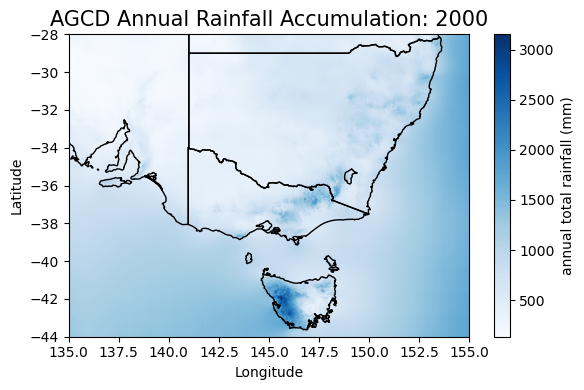

In [5]:
# Open file
ds1 = xr.open_dataset(
    "/g/data/zv2/agcd/v2-0-3/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_2000.nc"
)

pr1 = ds1["precip"]

# Annual accumulation
annual_rain = pr1.sum(dim="time")

# Southeast Australia subset
annual_rain_se = annual_rain.sel(
    lon=slice(135, 155),
    lat=slice(-44, -28)
)

# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 4))

# Rainfall map
annual_rain_se.plot(
    ax=ax,
    cmap="Blues",
    cbar_kwargs={"label": "annual total rainfall (mm)"}
)

# Australian state boundaries
states_shp = shpreader.natural_earth(
    resolution='10m',
    category='cultural',
    name='admin_1_states_provinces'
)

reader = shpreader.Reader(states_shp)

for rec in reader.records():

    if rec.attributes['admin'] == 'Australia':

        geom = rec.geometry

        if geom.geom_type == 'Polygon':

            x, y = geom.exterior.xy
            ax.plot(x, y, 'k-', linewidth=1)

        elif geom.geom_type == 'MultiPolygon':

            for poly in geom.geoms:

                x, y = poly.exterior.xy
                ax.plot(x, y, 'k-', linewidth=1)

#
ax.set_xlim(135, 155)
ax.set_ylim(-44, -28)

ax.set_title("AGCD Annual Rainfall Accumulation: 2000", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [6]:
# ---------------------------------------------------------------------
# 1. Load AGCD monthly precipitation
# ---------------------------------------------------------------------
ds = xr.open_mfdataset(
    "/g/data/zv2/agcd/v2-0-3/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_*.nc",
    combine="by_coords",
    chunks={"time": 120}
)

/jobfs/171408020.gadi-pbs/ipykernel_3969366/3438946291.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


In [7]:
#print(ds)

In [8]:
pr = ds["precip"]

# ensure time decoding
pr["time"] = xr.decode_cf(ds).time

In [9]:
# ---------------------------------------------------------------------
# 2. 12-month running mean (t-11 to t)
# ---------------------------------------------------------------------
pr_12m = pr.rolling(time=12, min_periods=12).mean()

In [10]:
# ---------------------------------------------------------------------
# 3. Select climatology period (1940–2024)
# ---------------------------------------------------------------------
clim = pr_12m.sel(time=slice("1940-01-01", "2024-12-31"))

# ---------------------------------------------------------------------
# 4. Compute 25th percentile at each grid cell
# ---------------------------------------------------------------------
p25 = clim.quantile(0.25, dim="time")

# ---------------------------------------------------------------------
# 5. Restrict drought evaluation to 1940–2024
# ---------------------------------------------------------------------
pr_12m_sel = pr_12m.sel(time=slice("1940-01-01", "2024-12-31"))

In [11]:
# align threshold and data
p25, pr_12m_sel = xr.align(p25, pr_12m_sel)

# ---------------------------------------------------------------------
# 6. Define drought (binary)
# ---------------------------------------------------------------------
drought = pr_12m_sel < p25
drought = drought.astype("int8")

drought.name = "hydrological_drought"

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 25
  result = blockwise(


In [12]:
print(drought.shape)

(1020, 691, 886)


In [13]:
# ==========================================================
# 1. Australia land mask
# ==========================================================

shp = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_0_countries"
)

reader = shpreader.Reader(shp)

for rec in reader.records():
    if rec.attributes["ADMIN"] == "Australia":
        aus_geom = prep(rec.geometry)
        break

lon = drought.lon.values
lat = drought.lat.values

lon2d, lat2d = np.meshgrid(lon, lat)

mask = np.zeros(lon2d.shape, dtype=bool)

for i in range(lat2d.shape[0]):
    for j in range(lat2d.shape[1]):
        mask[i, j] = aus_geom.covers(
            Point(lon2d[i, j], lat2d[i, j])
        )

land_mask = xr.DataArray(
    mask,
    coords={"lat": lat, "lon": lon},
    dims=("lat", "lon")
)

# ==========================================================
# 2. Apply mask
# ==========================================================

drought_land = drought.where(land_mask)

# ==========================================================
# 3. Cool season only (May-Oct)
# ==========================================================

cool = drought_land.sel(
    time=drought_land.time.dt.month.isin([5, 6, 7, 8, 9, 10])
)

# ==========================================================
# 4. Drought months per year
# ==========================================================

cool_count = cool.groupby("time.year").sum("time")

# Keep ocean as NaN
cool_count = cool_count.where(land_mask)

# ==========================================================
# 6. Southeast Australia
# ==========================================================

cool_count_se = cool_count.sel(
    lon=slice(135, 155),
    lat=slice(-44, -28)
)

In [14]:
# ==========================================================
# Load data into memory first
# ==========================================================

cool_count_se = cool_count_se.load()

# Check dimensions
print(cool_count_se.dims)
print(cool_count_se.shape)

# Determine time dimension
time_dim = cool_count_se.dims[0]
nframes = cool_count_se.sizes[time_dim]

('year', 'lat', 'lon')
(17, 321, 401)


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x400 -pix_fmt rgba -framerate 1.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /scratch/nf33/mm6452/GC2026_Project9/cool_season_drought_5yr.mp4


Saving movie...
Movie saved: /scratch/nf33/mm6452/GC2026_Project9/cool_season_drought_5yr.mp4


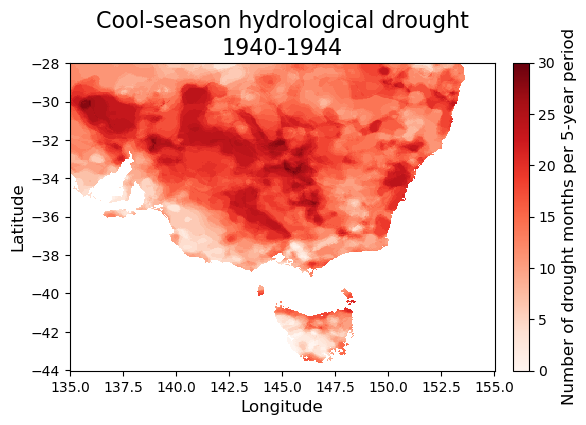

In [15]:
# ==========================================================
# White ocean
# ==========================================================

cmap = plt.cm.Reds.copy()
cmap.set_bad("white")

# ==========================================================
# Figure
# ==========================================================

fig, ax = plt.subplots(figsize=(6, 4))

vmin = 0
vmax = 6

# ==========================================================
# Animation function
# ==========================================================

def animate(i):

    ax.clear()

    plot_data = cool_5yr_se.isel({time_dim: i})

    plot_data.plot(
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    start_year = 1940 + i * 5
    end_year = min(start_year + 4, 2024)

    ax.set_title(
        f"Cool-season hydrological drought\n"
        f"{start_year}-{end_year}",
        fontsize=16
    )

    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)

# ==========================================================
# Animation
# ==========================================================

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=nframes,
    interval=1000,
    blit=False,
    repeat=True
)

# ==========================================================
# Shared colorbar
# ==========================================================

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Number of drought months per year period",
    fontsize=12
)

# ==========================================================
# Save movie
# ==========================================================

outfile = (
    "/scratch/nf33/mm6452/GC2026_Project9/"
    "cool_season_drought_5yr.mp4"
)

print("Saving movie...")

ani.save(
    outfile,
    writer="ffmpeg",
    dpi=100
)

print(f"Movie saved: {outfile}")